<a href="https://colab.research.google.com/github/nayaritpantoja/AYP-2026/blob/main/cirug%C3%ADas_oncol%C3%B3gicas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = r"/content/drive/MyDrive/Cancer_cirugías.csv"
data = pd.read_csv(file_path, encoding='latin1', sep=';')
data.head()

,Year,County,hospital,OSHPDID,Surgery,# of Cases,LONGITUDE,LATITUDE
0,2024,Alameda,Alameda Hospital,106010735.0,Colon,2,-1.222.541.062,377.626.798
1,2024,Alameda,Alta Bates Summit Medical Center,106010937.0,Bladder,1,-12.226.304,37.821.175
2,2024,Alameda,Alta Bates Summit Medical Center,106010937.0,Breast,408,-12.226.304,37.821.175
3,2024,Alameda,Alta Bates Summit Medical Center,106010937.0,Colon,49,-12.226.304,37.821.175
4,2024,Alameda,Alta Bates Summit Medical Center,106010937.0,Esophagus,3,-12.226.304,37.821.175


In [ ]:
data.shape

(23178, 8)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23178 entries, 0 to 23177
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Year        23178 non-null  int64  
 1   County      23046 non-null  object 
 2   hospital    23178 non-null  object 
 3   OSHPDID     23046 non-null  float64
 4   Surgery     23178 non-null  object 
 5   # of Cases  23178 non-null  int64  
 6   LONGITUDE   23039 non-null  object 
 7   LATITUDE    23039 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


In [ ]:
data.isna().sum()

,0
Year,0
County,132
hospital,0
OSHPDID,132
Surgery,0
# of Cases,0
LONGITUDE,139
LATITUDE,139


In [ ]:
print(data.duplicated().sum())

0


In [ ]:
data.columns

Index(['Year', 'County', 'hospital', 'OSHPDID', 'Surgery', '# of Cases',
       'LONGITUDE', 'LATITUDE'],
      dtype='object')

In [ ]:
data.drop("OSHPDID", axis=1, inplace=True)

In [ ]:
data.drop(["LONGITUDE","LATITUDE"], axis=1, inplace=True)

In [ ]:
data.dropna(inplace=True)

In [ ]:
data.info()
print(data)

<class 'pandas.core.frame.DataFrame'>
Index: 23046 entries, 0 to 23166
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Year        23046 non-null  int64 
 1   County      23046 non-null  object
 2   hospital    23046 non-null  object
 3   Surgery     23046 non-null  object
 4   # of Cases  23046 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 1.1+ MB
       Year   County                          hospital    Surgery  # of Cases
0      2024  Alameda                  Alameda Hospital      Colon           2
1      2024  Alameda  Alta Bates Summit Medical Center    Bladder           1
2      2024  Alameda  Alta Bates Summit Medical Center     Breast         408
3      2024  Alameda  Alta Bates Summit Medical Center      Colon          49
4      2024  Alameda  Alta Bates Summit Medical Center  Esophagus           3
...     ...      ...                               ...        ...         ...
23162  2013     Yuba 

In [ ]:
data['# of Cases'].describe()

,# of Cases
count,23046.000000
mean,28.362015
std,62.971221
min,1.000000
25%,2.000000
50%,8.000000
75%,26.000000
max,959.000000


In [ ]:
c_por_a=data.groupby('Year')['# of Cases'].sum()

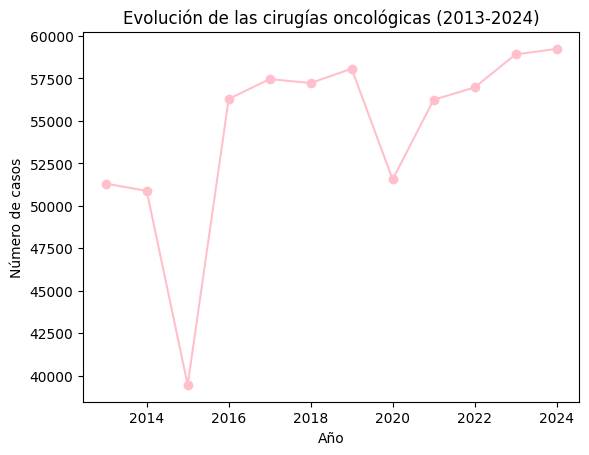

In [ ]:
c_por_a.plot(kind='line', color='pink', marker='o')
plt.title('Evolución de las cirugías oncológicas (2013-2024)')
plt.xlabel('Año')
plt.ylabel('Número de casos')
plt.show()

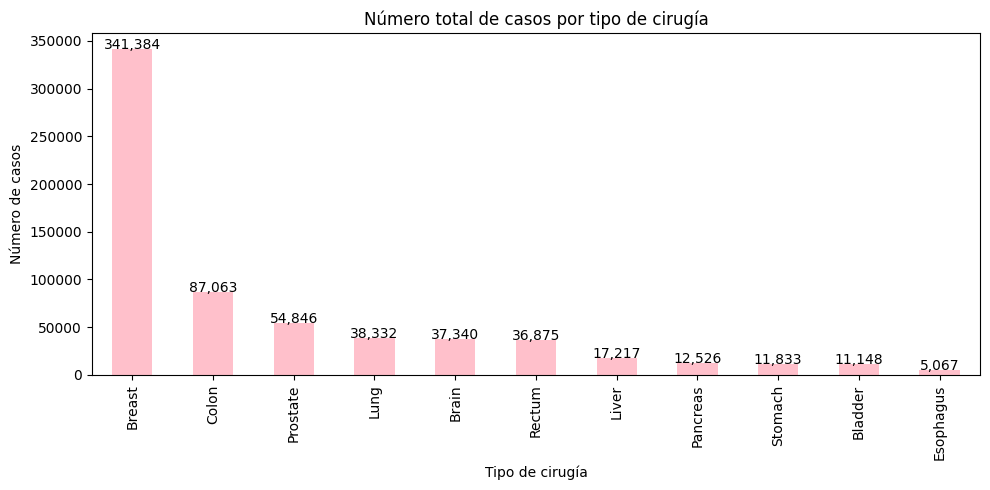

In [ ]:
cirugias= data.groupby('Surgery')['# of Cases'].sum().sort_values(ascending=False)
ax= cirugias.plot(kind='bar',color='pink',figsize=(10,5))
plt.title('Número total de casos por tipo de cirugía')
plt.xlabel('Tipo de cirugía')
plt.ylabel('Número de casos')

for i, v in enumerate(cirugias):
  ax.text(i,v,f'{v:,}', ha='center')
plt.tight_layout()
plt.show()

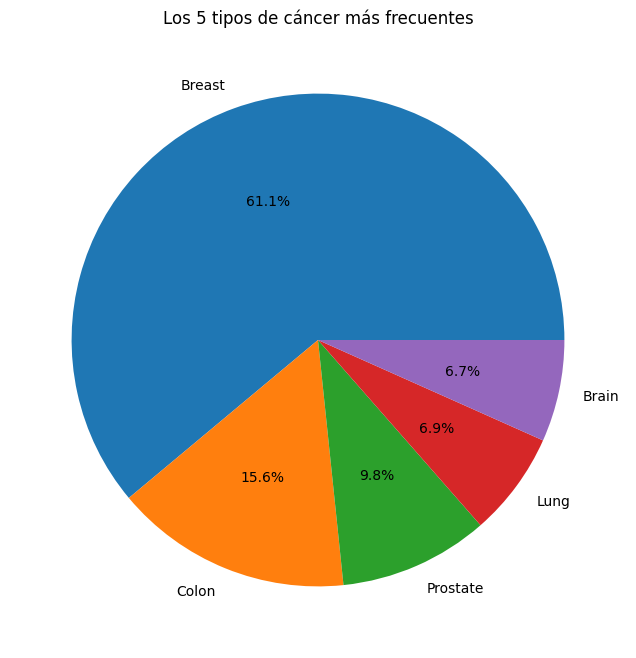

In [ ]:
top5 = data.groupby('Surgery')['# of Cases'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,8))
plt.pie(top5,labels=top5.index, autopct='%1.1f%%')

plt.title('Los 5 tipos de cáncer más frecuentes')
plt.show()

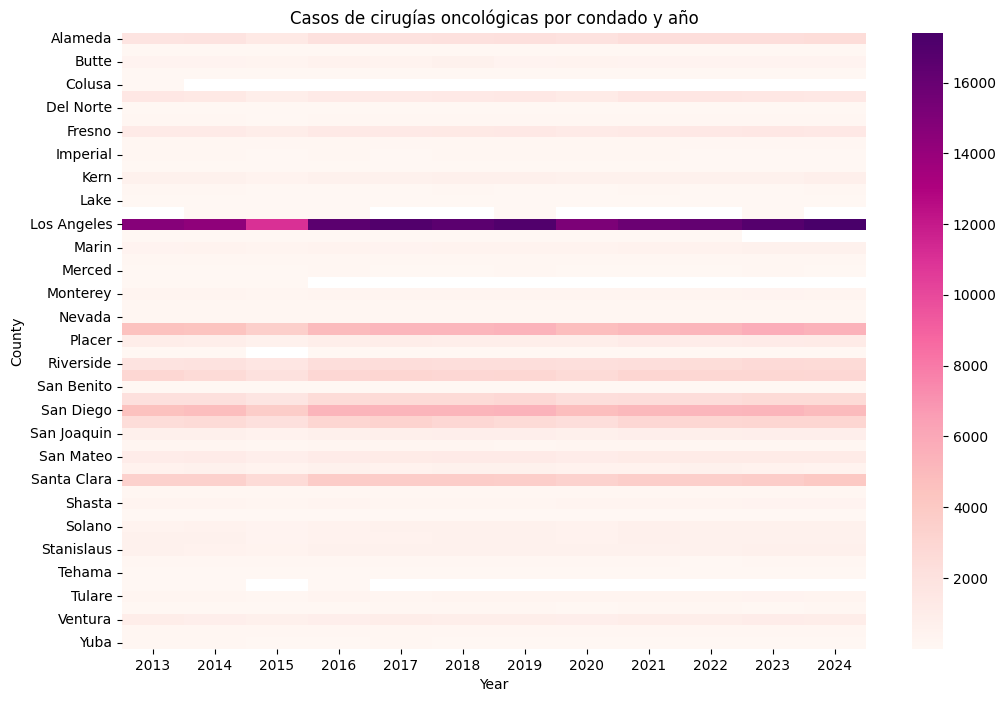

In [ ]:
import seaborn as sns
tabla = data.pivot_table(
    values='# of Cases',index='County',columns='Year',aggfunc='sum')

plt.figure(figsize=(12,8))

sns.heatmap(tabla,cmap='RdPu')

plt.title('Casos de cirugías oncológicas por condado y año')
plt.show()

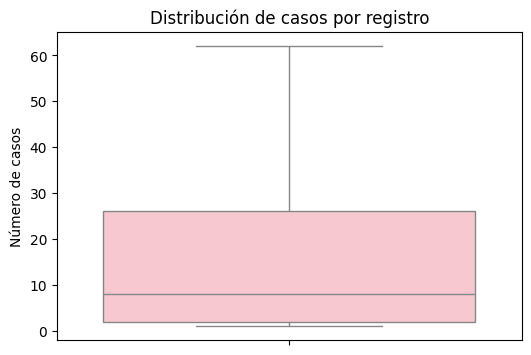

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.boxplot(y=data['# of Cases'],color='pink',showfliers=False)

plt.title('Distribución de casos por registro')
plt.ylabel('Número de casos')

plt.show()